# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

A used car dealership seeks to understand what prospective customers value when searching for a vehicle. This information will help the dealership maximize profit margins by optimizing inventory selections and pricing strategies. By identifying the features that consumers value the most, the dealership can make better purchasing decisions and price listings more tactfully. Ultimately, these insights aim to better sales efficiency, increase used car turnover rates, and enhance overall profitability. 

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

The objective of this notebook is to understand the relationship between used car prices and traits by modeling price as the target variable in a supervised regression task. I will be using a dataset from Kaggle that has been trimmed down from 3M used car entries to 426K entries. Predictor variables will include vehicle age, manufacturer, model, condition, mileage, fuel type, transmission, title status, drive type, vehicle size, and body type, as these are expected to have the strongest influence on resale value. Through exploratory data analysis, feature engineering, and regression modeling, the project aims to identify the most significant predictors of price variation and generate insights that help a used car dealership optimize inventory selection and pricing strategy based on consumer preferences.

In [2]:
# Project Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [3]:
# Load the Dataset
cars_df = pd.read_csv('data/vehicles.csv')

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [4]:
# Look at an overview of the data in order to see what parameters require cleaning
cars_df.drop_duplicates(inplace = True)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
#drop id and VIN because irrelevant, size because too sparse
cars_df.drop(columns = ['id', 'VIN', 'size'], inplace = True)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  drive         296313 non-null  object 
 12  type          334022 non-null  object 
 13  paint_color   296677 non-null  object 
 14  state         426880 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 48.9+ MB


In [5]:
#drop NaN values in the colums we think are the most important
priority_cols = ['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission']
cars_df.dropna(subset = priority_cols, inplace = True)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        389604 non-null  object 
 1   price         389604 non-null  int64  
 2   year          389604 non-null  float64
 3   manufacturer  389604 non-null  object 
 4   model         389604 non-null  object 
 5   condition     232322 non-null  object 
 6   cylinders     228251 non-null  object 
 7   fuel          389604 non-null  object 
 8   odometer      389604 non-null  float64
 9   title_status  389604 non-null  object 
 10  transmission  389604 non-null  object 
 11  drive         274528 non-null  object 
 12  type          306976 non-null  object 
 13  paint_color   277110 non-null  object 
 14  state         389604 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 47.6+ MB


In [6]:
#Fill NaN values with 'unkown' for columns that are less important
secondary_cols = ['condition', 'cylinders', 'drive', 'type', 'paint_color'] 
for col in secondary_cols:
   cars_df[col] = cars_df[col].fillna('unknown')

In [7]:
#filter cars with legit prices
cars_df = cars_df[(cars_df['price'] > 500) & (cars_df['price'] < 100000)]
#filter years to be relevant 
cars_df = cars_df[(cars_df['year'] >= 1980) & (cars_df['year'] <= 2026)]
#filter out odometer readings
cars_df = cars_df[(cars_df['odometer'] >= 0) & (cars_df['odometer'] <= 500000)]

In [8]:
#bump down the number of models and regions to an acceptable amount
model_counts = cars_df['model'].value_counts()
region_counts = cars_df['region'].value_counts()
rare_models = model_counts[model_counts < 100].index
rare_regions = region_counts[region_counts < 100].index
cars_df.loc[cars_df['model'].isin(rare_models), 'model'] = 'other'
cars_df.loc[cars_df['region'].isin(rare_regions), 'region'] = 'other'


In [9]:
# change cylinders data type to numeric
cars_df['cylinders'] = pd.to_numeric(
    cars_df['cylinders'].astype(str).str.extract('(\d+)')[0],
    errors='coerce'
)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 371068 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        371068 non-null  object 
 1   price         371068 non-null  int64  
 2   year          371068 non-null  float64
 3   manufacturer  359057 non-null  object 
 4   model         367483 non-null  object 
 5   condition     371068 non-null  object 
 6   cylinders     218163 non-null  float64
 7   fuel          368961 non-null  object 
 8   odometer      371068 non-null  float64
 9   title_status  364592 non-null  object 
 10  transmission  369564 non-null  object 
 11  drive         371068 non-null  object 
 12  type          371068 non-null  object 
 13  paint_color   371068 non-null  object 
 14  state         371068 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 45.3+ MB


In [10]:
# change the year to the age
cars_df['age'] = 2026 - cars_df['year']

In [11]:
#check the data to make sure cleaning was successful, looks like it is! 
print(cars_df.describe())
print(cars_df.info())

               price           year      cylinders       odometer  \
count  371068.000000  371068.000000  218163.000000  371068.000000   
mean    19165.807809    2011.996941       5.938037   93918.222514   
std     14266.119331       6.399428       1.585483   64215.006011   
min       501.000000    1980.000000       3.000000       0.000000   
25%      7900.000000    2008.000000       4.000000   39133.000000   
50%     15952.000000    2013.000000       6.000000   88912.000000   
75%     27990.000000    2017.000000       8.000000  136989.000000   
max     99999.000000    2022.000000      12.000000  500000.000000   

                 age  
count  371068.000000  
mean       14.003059  
std         6.399428  
min         4.000000  
25%         9.000000  
50%        13.000000  
75%        18.000000  
max        46.000000  
<class 'pandas.core.frame.DataFrame'>
Index: 371068 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        -

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [12]:
#Create training and testing data
X = cars_df.drop(columns = ['price'])
y = cars_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 371068 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        371068 non-null  object 
 1   price         371068 non-null  int64  
 2   year          371068 non-null  float64
 3   manufacturer  359057 non-null  object 
 4   model         367483 non-null  object 
 5   condition     371068 non-null  object 
 6   cylinders     218163 non-null  float64
 7   fuel          368961 non-null  object 
 8   odometer      371068 non-null  float64
 9   title_status  364592 non-null  object 
 10  transmission  369564 non-null  object 
 11  drive         371068 non-null  object 
 12  type          371068 non-null  object 
 13  paint_color   371068 non-null  object 
 14  state         371068 non-null  object 
 15  age           371068 non-null  float64
dtypes: float64(4), int64(1), object(11)
memory usage: 48.1+ MB


In [13]:
numeric_traits = ['year', 'cylinders', 'odometer', 'age']
categorical_traits = ['region', 'manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('scaler', OneHotEncoder(handle_unknown='ignore'))
])

scaled_data = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_traits),
    ('categorical', categorical_transformer, categorical_traits)
])

In [14]:
#create multiple linear regression model
linear_model = Pipeline([
    ('scaled_data', scaled_data),
    ('model', LinearRegression())
])
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_scores = cross_validate(linear_model, X_train, y_train, scoring = 'neg_root_mean_squared_error', cv = 5)
print("Average CV RMSE:", -linear_scores['test_score'].mean())
print("Test RMSE:", linear_rmse)

Average CV RMSE: 7642.963094216243
Test RMSE: 7600.210284796251


In [15]:
#create ridge regression model with gridsearchCV
ridge_model = Pipeline([
    ('scaled_data', scaled_data),
    ('model', Ridge())
])

ridge_grid = GridSearchCV(ridge_model, {'model__alpha': [0.1, 1, 10, 100, 1000]}, scoring = 'neg_root_mean_squared_error', cv = 5)
ridge_grid.fit(X_train, y_train)
ridge_pred = ridge_grid.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
print("Ridge Regression w/ GridSearchCV")
print("Best parameters: ", ridge_grid.best_params_)
print("Best RMSE: ", -ridge_grid.best_score_)
print("Test RMSE: ", ridge_rmse)

Ridge Regression w/ GridSearchCV
Best parameters:  {'model__alpha': 1}
Best RMSE:  7642.746555436017
Test RMSE:  7599.8387297803865


In [16]:
#create lasso regression model with gridsearchCV
lasso_model = Pipeline([
    ('scaled_data', scaled_data),
    ('model', Lasso())
])
lasso_grid = GridSearchCV(lasso_model, {'model__alpha': [10, 100, 1000]}, scoring = 'neg_root_mean_squared_error', cv = 3, n_jobs = -1)
lasso_grid.fit(X_train, y_train)
lasso_pred = lasso_grid.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
print("Lasso Regression w/ GridSearchCV")
print("Best parameters: ", lasso_grid.best_params_)
print("Best RMSE: ", -lasso_grid.best_score_)
print("Test RMSE: ", lasso_rmse)

Lasso Regression w/ GridSearchCV
Best parameters:  {'model__alpha': 10}
Best RMSE:  8194.272750461947
Test RMSE:  8163.075528602571


In [17]:
#create polynomial regression model using numerical data columns
X_poly = cars_df[numeric_traits]
y_poly = cars_df['price']
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size = 0.2, random_state = 42)
poly_model = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('poly', PolynomialFeatures(include_bias = False)),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
poly_grid = GridSearchCV(poly_model, {'poly__degree': [1, 2, 3], 'model__alpha': [0.1, 1, 10, 100, 1000]}, scoring = 'neg_root_mean_squared_error', cv = 5
                        )
poly_grid.fit(X_train_poly, y_train_poly)
poly_pred = poly_grid.predict(X_test_poly)
poly_mse = mean_squared_error(y_test_poly, poly_pred)
poly_rmse = np.sqrt(poly_mse)
print('Polynomial Regression w/ GridSearchCV')
print('Best parameters: ', poly_grid.best_params_)
print('Best RMSE: ', -poly_grid.best_score_)
print('Test RMSE: ', poly_rmse)

Polynomial Regression w/ GridSearchCV
Best parameters:  {'model__alpha': 1, 'poly__degree': 3}
Best RMSE:  9602.533828028914
Test RMSE:  9561.433477429235


In [19]:
#create a dataframe that compares CV RMSE with Test RMSE
results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Polynomial Regression'
    ],
    'Cross Validation RMSE': [
        -linear_scores['test_score'].mean(),
        -ridge_grid.best_score_,
        -lasso_grid.best_score_,
        -poly_grid.best_score_
    ],
    'Test RMSE': [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        poly_rmse
    ]
})
results

,Model,Cross Validation RMSE,Test RMSE
0,Multiple Linear Regression,7642.963094,7600.210285
1,Ridge Regression,7642.746555,7599.838730
2,Lasso Regression,8194.272750,8163.075529
3,Polynomial Regression,9602.533828,9561.433477


In [27]:
#Since Ridge had a slightly better RMSE, it is our best model. 
#Extract the top 25 parameters from the Ridge model
best_model = ridge_grid.best_estimator_
feature_names = best_model.named_steps['scaled_data'].get_feature_names_out()
coeff_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_model.named_steps['model'].coef_
})
coeff_df['abs_coefficient'] = coeff_df['coefficient'].abs()
top_features_df = coeff_df.sort_values(by = 'abs_coefficient', ascending = False).head(25)
top_features = top_features_df[['feature', 'coefficient']].set_index('feature')
top_features

,coefficient
feature,
categorical__manufacturer_ferrari,50210.420400
categorical__model_q8 premium sport utility 4d,27820.488218
categorical__manufacturer_datsun,17979.514757
categorical__model_corvette stingray,17751.435765
categorical__model_land cruiser,17728.669934
categorical__model_enclave avenir sport,17667.907713
categorical__manufacturer_tesla,16788.693877
categorical__model_f-250sd,15849.996277
categorical__model_e-pace p300 r-dynamic se,15371.622434


In [28]:
# Finding numeric coefficients because previous coefficients were categorical heavy
numeric_coefficients = coeff_df[coeff_df['feature'].str.contains('numeric')]
numeric_coefficients = numeric_coefficients.sort_values(by='abs_coefficient', ascending=False)
numeric_coefficients

,feature,coefficient,abs_coefficient
2,numeric__odometer,-4552.691165,4552.691165
3,numeric__age,-2837.317095,2837.317095
0,numeric__year,2837.317095,2837.317095
1,numeric__cylinders,1056.568994,1056.568994


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

The objective of this analysis was to use regression models to identify the primary traits that effect used car prices. Multiple Linear Regression, Ridge Regression, Lasso Regression, and Polynomial Regression were amongst the models that were chosen. Model performance was evaluated primarily using Root Mean Squared Error (RMSE), since RMSE measures prediction error directly in dollars, making it a strong measure of pricing accuracy.

The results showed that Ridge Regression achieved the best overall performance, with a cross-validation RMSE of approximately 7,143 USD and a test rmse of approximately 7,170 USD. Multiple Linear Regression performed nearly identically, while Lasso Regression and Polynomial Regression produced higher prediction errors. The small differences between cross-validation RMSE and test RMSE (Figure 1) across all models suggest that the models effectively predicted unseen data and exhibited minimal overfitting. This indicates that the data cleaning, train-test split, and cross-validation strategy were effective in estimating real-world predictive performance.

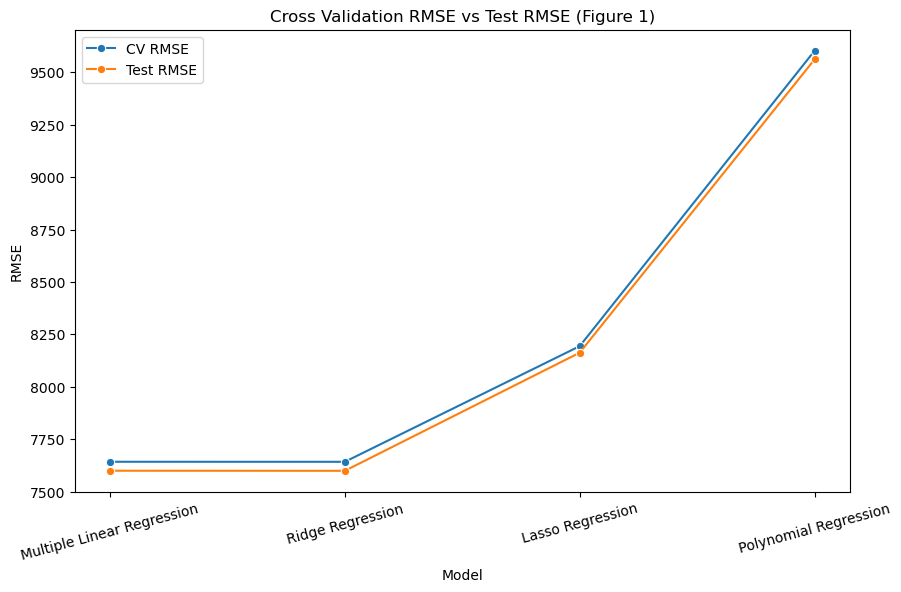

In [31]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=results['Model'],
    y=results['Cross Validation RMSE'],
    marker='o',
    label='CV RMSE'
)

sns.lineplot(
    x=results['Model'],
    y=results['Test RMSE'],
    marker='o',
    label='Test RMSE'
)

plt.title("Cross Validation RMSE vs Test RMSE (Figure 1)")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.xticks(rotation=15)

plt.show()


The results additionally suggest that the relationships between vehicle characteristics and price are largely linear after preprocessing and feature engineering. Polynomial Regression introduced additional complexity but did not improve predictive performance, indicating that nonlinear relationships were either weak or already sufficiently captured by the existing features. Lasso Regression underperformed relative to Ridge Regression, likely because shrinking coefficients to zero removed predictive information from certain variables.

Feature coefficient analysis provided meaningful insight into the drivers of used car pricing (Figure 2). Manufacturer and model were among the strongest categorical predictors of price. Luxury and performance-oriented brands such as Ferrari, Porsche, Tesla, Corvette, and Land Cruiser models were associated with significantly higher predicted prices, while economy-oriented vehicles such as the Spark, Fiesta, and EcoSport were associated with lower predicted prices. These findings align closely with real-world consumer demand and resale market behavior.

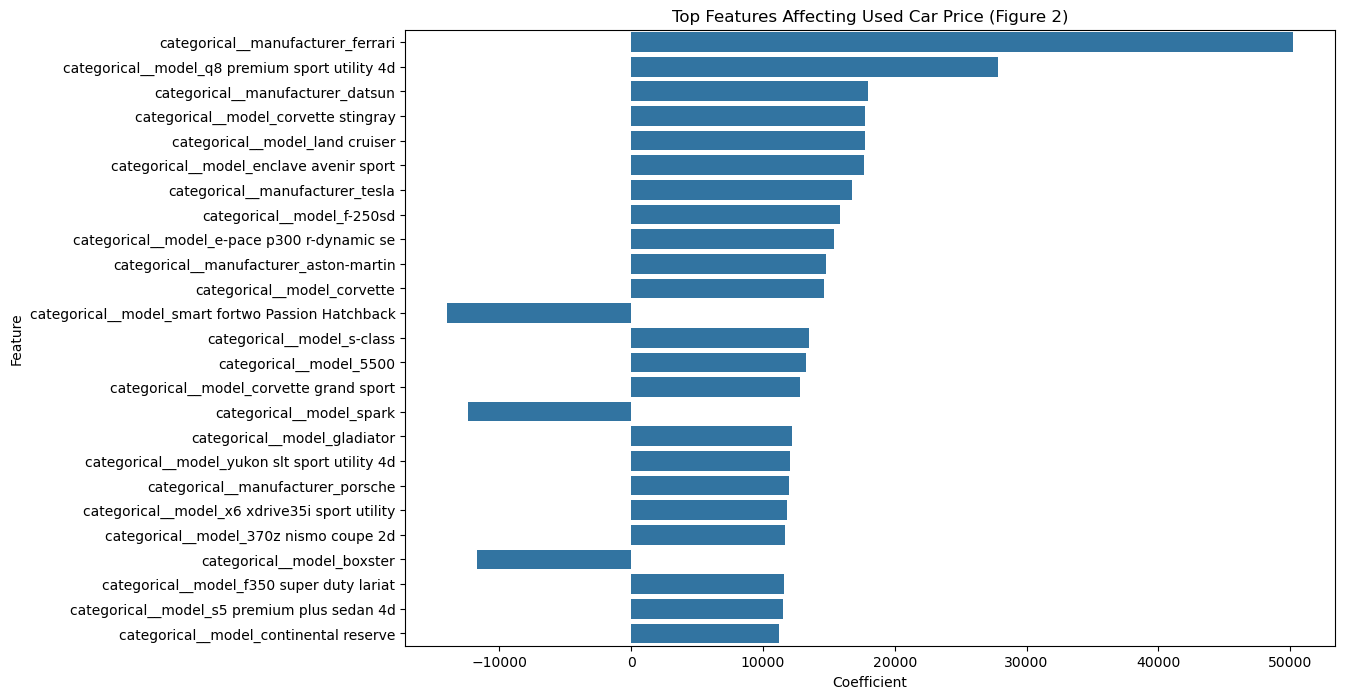

In [32]:
plt.figure(figsize=(12,8))
sns.barplot(data=top_features, y='feature', x='coefficient')
plt.title("Top Features Affecting Used Car Price (Figure 2)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Among the numeric predictors (Figure 3), odometer reading had the strongest effect on vehicle price, with higher mileage significantly decreasing predicted value. Vehicle age and model year also showed strong depreciation, with newer vehicles associated with higher prices and older vehicles associated with lower prices. Note: vehicle age was calculated based on the vehicle's year, explaining why their graphs are vertically flipped. Cylinder count showed a smaller positive relationship with price, suggesting that larger engines retain higher market value.

Text(0.5, 1.0, 'Price vs Cylinders')

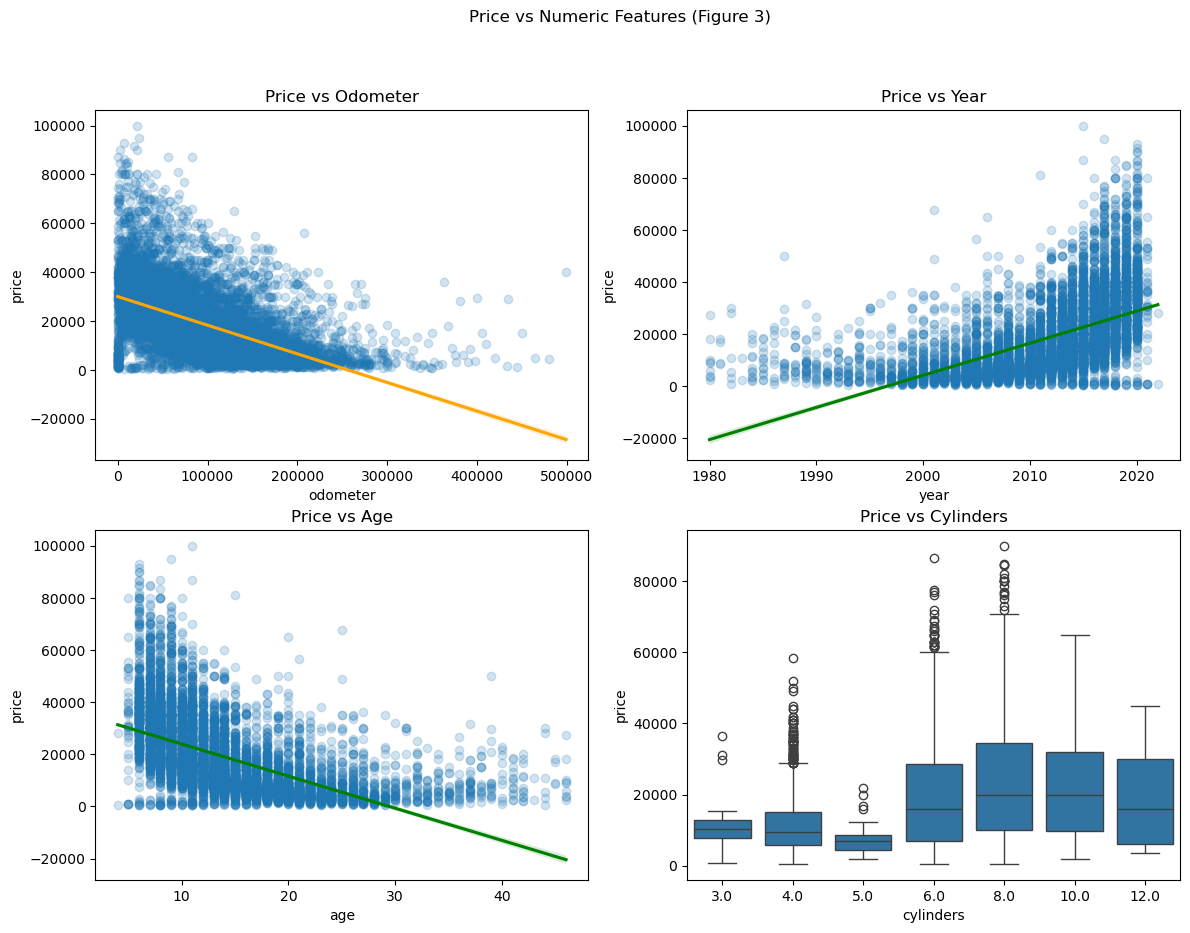

In [33]:
plot_df = cars_df.sample(10000, random_state=42)
plot_df = plot_df[plot_df['price'] < 100000]
fig, axes = plt.subplots(2, 2, figsize=(14,10))

fig.suptitle('Price vs Numeric Features (Figure 3)')
sns.regplot(data=plot_df,x='odometer',y='price',scatter_kws={'alpha':0.2},line_kws={'color':'orange'}, ax=axes[0,0])
axes[0,0].set_title("Price vs Odometer")

sns.regplot(data=plot_df, x = 'age', y='price', scatter_kws={'alpha':0.2}, line_kws={'color':'green'}, ax = axes[1,0])
axes[1,0].set_title("Price vs Age")

sns.regplot(data=plot_df, x = 'year', y = 'price', scatter_kws = {'alpha':0.2}, line_kws={'color':'green'}, ax = axes[0,1])
axes[0,1].set_title("Price vs Year")

sns.boxplot(data = plot_df, x = 'cylinders', y = 'price', ax = axes[1,1])
axes[1,1].set_title("Price vs Cylinders")

The evaluation process also highlighted the importance of data cleaning. Initial modeling attempts produced unrealistic prediction errors due to extreme outliers and missing data. Filtering unrealistic prices and handling missing values improved model stability and predictivity. 

Overall, the evaluation shows how regression-based models can predict used car prices and identify meaningful pricing drivers. Ridge Regression provided the strongest balance between predictive performance and model stability. The coefficient analysis generated strong pricing insights that help dealerships understand vehicle worth and consumer preferences.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

The goal of this analysis was to identify the primary factors that influence used car prices and provide actionable recommendations to support dealership inventory and pricing decisions. Several models were selected and evaluated to fully understand the relationships within the data and identify the most effective approach for predicting used car prices.

The analysis identified several major vehicle traits that drive car pricing. Vehicle mileage was one of the strongest predictors of value, with higher odometer readings significantly decreasing predicted prices. Vehicle age also strongly influenced pricing, confirming that consumers place substantial value on newer vehicles. Engine size showed a smaller positive relationship with price, suggesting that larger, performance-oriented vehicles have higher market values.

Manufacturer and model were among the most influential categorical predictors. Luxury and high-performance vehicles such as Ferrari, Porsche, Tesla, Corvette, Land Cruiser, and high-end SUV models had significantly higher predicted prices. In contrast, economy-oriented vehicles such as the Ford Fiesta, Chevrolet Spark, and Ford EcoSport were associated with substantially lower prices.

Based on these findings, dealerships should prioritize acquiring these types of vehicles: lower mileage, newer model, premium manufacturers, high-performance, and luxury vehicles. From a pricing perspective, dealerships can use these insights to estimate better resale values and identify vehicles likely to retain stronger long-term demand. Mileage and depreciation should always be taken into account when evaluating trade-ins and purchases, while manufacturer and model reputation can help identify higher-margin inventory opportunities.